# Régression  polynomiale



La régression polynomiale est un type d'analyse de régression dans lequel la relation entre la variable indépendante x et la variable dépendante y est modélisée sous la forme d'un polynôme de degré n. Il s'agit d'une extension de la régression linéaire, qui ne modélise que les relations linéaires entre les variables.

Dans la régression polynomiale, la relation entre x et y est représentée par une équation polynomiale, qui peut saisir des relations plus complexes, y compris la courbure et d'autres modèles non linéaires. Le degré de l'équation polynomiale détermine le niveau de complexité de la relation.

La forme générale d'une équation de régression polynomiale est la suivante:

$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_n x^n$

x: variable indépendante

y: variable dépendante

$\beta_0$ : ordonnée à l'origine (intercept)

$\beta_i$ : coefficents/paramètres du modèle de régression, $i \in [1,n]$

n: degré du polynôme

On va implémenter ce modèle de régression avec la bibliothèque "LinearRegression" de SkicitLearn



1) Importer les librairies nécessaires comme numpy, pandas, matplolib

In [1]:
# votre code
import numpy as np 

import pandas as pd 

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
import scipy

2. Importer le fichier data_RP.csv dans un DataFrame

In [2]:
# votre code
df = pd.read_csv('data_RP.csv')

3. Analyse de données (info, describe)

In [3]:
# votre code
print("Info")
df.info()

print("\nStatistics")
df.describe()

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  50 non-null     int64  
 1   x           50 non-null     float64
 2   y           50 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.3 KB

Statistics


,Unnamed: 0,x,y
count,50.00000,50.000000,50.000000
mean,24.50000,-0.415289,3.919848
std,14.57738,2.050865,2.289413
min,0.00000,-3.863276,-0.516434
25%,12.25000,-2.104893,2.483102
50%,24.50000,-0.517398,3.461637
75%,36.75000,1.609243,5.173983
max,49.00000,2.856850,9.165108


4) Tracer le nuage de points de l'ensemble y(x)

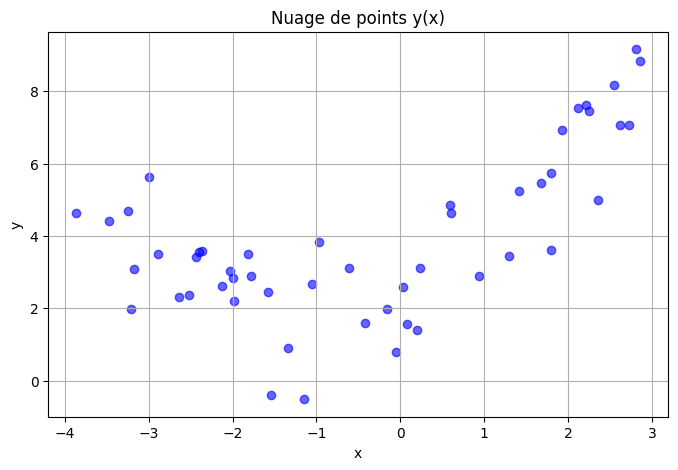

In [4]:
# votre code
plt.figure(figsize=(8, 5))
plt.scatter(df['x'], df['y'], color='blue', alpha=0.6)
plt.title("Nuage de points y(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

Remarque: La relation y(x) est non linéaire, nous allons utiliser le modèle de régression polynomiale pour la reprénseter. Il faut tout d'abord construire les emsembles de données train et test 

5. Définir x et y, ensuite séparer en train et test (test_size =0.3)

Vérifier ensuite le pourcentage de la séparation 

In [5]:
# votre code
from sklearn.model_selection import train_test_split

X = df[['x']] 
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set % : {len(X_train) / len(X) * 100:.2f} %")
print(f"Test set %: {len(X_test) / len(X) * 100:.2f} %")

Training set % : 70.00 %
Test set %: 30.00 %


6. Représenter sur un même graphique les nuages de points de l'ensemble d'entraînement et de test, en utilisant des couleurs distinctes.

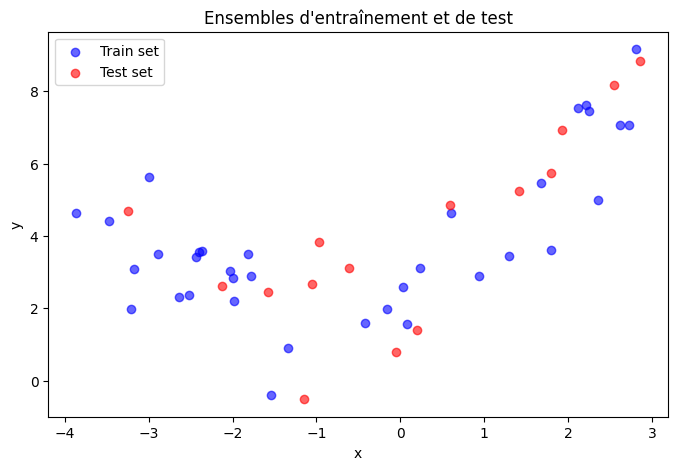

In [6]:
# votre code
plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, color='blue', label='Train set', alpha=0.6)

plt.scatter(X_test, y_test, color='red', label='Test set', alpha=0.6)

plt.title("Ensembles d'entraînement et de test")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

7. De quel degré doit être le polynôme pour bien représenter y(x) ?

Créer ce polynôme avec PolynomialFeatures de ScikitLearn https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html

Given that the data show a parabolic shape, the polynomial degree that best fits the distribution of y(x) is 2. 

In [7]:
# votre code
from sklearn.preprocessing import PolynomialFeatures

#parabolic shape
degree = 2 

#creation of the polynome
poly = PolynomialFeatures(degree=degree, include_bias=False)

8. Créer les nouvelles variables "indépendantes" à partir de x_train et le polynôme de la question 7 (utiliser "fit_transform")

Créer un modèle de régression linéaire https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

Entrainer le modèle.


In [8]:
# votre code
from sklearn.linear_model import LinearRegression

X_train_poly = poly.fit_transform(X_train)
model = LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


9. Faire la prédiction pour les ensembles de train et test.

Pour chaque ensemble de données, affichier le score et l'erreur RMSE 

In [9]:
# votre code
from sklearn.metrics import mean_squared_error
import numpy as np

X_test_poly = poly.transform(X_test)


y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)


score_train = model.score(X_train_poly, y_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("Trainig set")
print(f"Score (R2) : {score_train:.4f}")
print(f"Erreur RMSE : {rmse_train:.4f}")


score_test = model.score(X_test_poly, y_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nTest set")
print(f"Score (R2) : {score_test:.4f}")
print(f"Erreur RMSE : {rmse_test:.4f}")

Trainig set
Score (R2) : 0.7482
Erreur RMSE : 1.0628

Test set
Score (R2) : 0.7689
Erreur RMSE : 1.2379


10. Afficher les coefficients du modèle de régression: intercept_ et coef_

In [10]:
# votre code
print("intercept:", model.intercept_)
print("coef_ :", model.coef_)

intercept: 2.394196496820697
coef_ : [0.87370892 0.41309658]


12. Visualiser graphiquement le polynôme du modèle de régression polynomiale.

Mettre sur le même graphique le nuage de point de la base de données y(x).

c:\Users\ignac\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


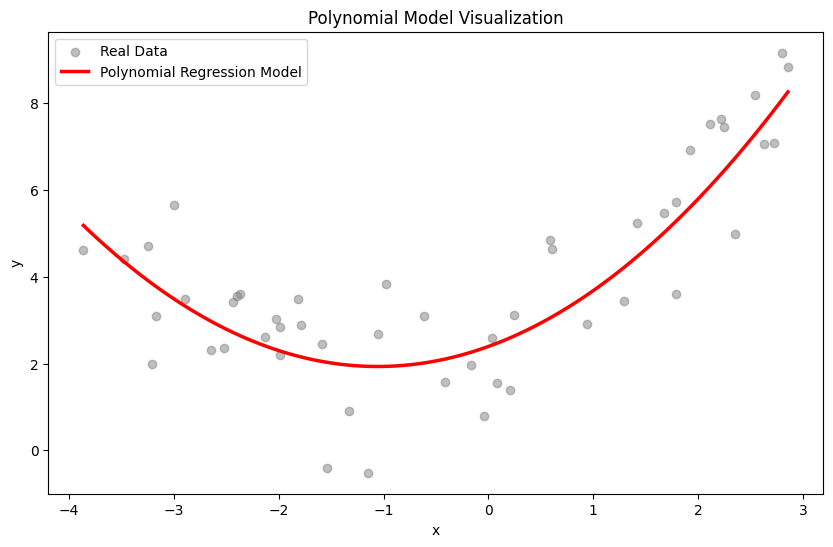

In [11]:
# votre code
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='gray', label='Real Data', alpha=0.5)

x_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

x_plot_poly = poly.transform(x_plot)
y_plot_pred = model.predict(x_plot_poly)

plt.plot(x_plot, y_plot_pred, color='red', label='Polynomial Regression Model', linewidth=2.5)

plt.title("Polynomial Model Visualization")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

13. Pourquoi le modèle de "régression linéaire" peut être utilisé pour faire la régression polynomiale?

The linear regression model can be used because polynomial regression is actually a special case of multiple linear regression.The term "linear" refers to the coefficients (beta)and not the variables "x". When using PolynomialFeatures, we are creating new variables (x^2, x^3, \dots, x^n). The final equation is a linear combination of these variables, making the use of linear regression possible.

14. Comparer les performances (RMSE et R2 sur les 2 ensembles train et test) avec 3 degrés suivants du polynôme: n = 1, n = 2 et n = 15.

Que remarquez-vous?

Votre réponse:

In [12]:
# votre code
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

degrees = [1, 2, 15]

for n in degrees:
    poly = PolynomialFeatures(degree=n, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
   
    modele = LinearRegression()
    modele.fit(X_train_poly, y_train)

    y_train_pred = modele.predict(X_train_poly)
    y_test_pred = modele.predict(X_test_poly)
    
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    print(f"Model of degree {n}")
    print(f"Train -> R2 : {r2_train:.4f} | RMSE : {rmse_train:.4f}")
    print(f"Test  -> R2 : {r2_test:.4f} | RMSE : {rmse_test:.4f}\n")

Model of degree 1
Train -> R2 : 0.3341 | RMSE : 1.7282
Test  -> R2 : 0.3718 | RMSE : 2.0411

Model of degree 2
Train -> R2 : 0.7482 | RMSE : 1.0628
Test  -> R2 : 0.7689 | RMSE : 1.2379

Model of degree 15
Train -> R2 : 0.8699 | RMSE : 0.7640
Test  -> R2 : 0.5445 | RMSE : 1.7379



# Remarks: 

For n = 1, we see a problem of underfitting. The model performs poorly both in the training set and the test set (R squared of around 0.33-0.37). This is also the model with the highest errors for both of the sets.

For n = 2, the performace improves significantly and it is balanced. The R squared coefficient is better in the training set, as well as in the test set (0.74 - 0.76). The error has also dropped in comparison to the case where n = 1. This is consistent with our prior observation of the data being distributed approximately as a parabola. 

For n = 15, we have overfitting. The score R squared is high for the training set (0.87, the highest among the three), but on the test data it falls to 0.54. The error also follows this overfitting tendency, it is low for the training set and high for the test set. This polynomial "memorizes" the training data, rather than making accurate predictions. 